In [9]:
import re 
import pandas as pd
from collections import Counter


In [34]:
#%% Help functions
def sort_dict(d):
    return dict(sorted(d.items(), key=lambda item: (-len(item[1]), item[0])))

def sort_list(lst):
    return sorted(lst, key=lambda item: (-len(item[1]), item[0]))

In [10]:
df = pd.read_csv("/Users/kaitaoyang/Downloads/datasets_conversations/DailyDialog/train.csv")
print(df.shape)
df.head(2)

(11118, 3)


,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]


In [11]:
text_raw = " ".join(df.dialog.to_list()).lower()
text_clean_list = re.findall(r"[a-zA-Z\-]+", text_raw)
text_clean_list[:100]

['say',
 'jim',
 'how',
 'about',
 'going',
 'for',
 'a',
 'few',
 'beers',
 'after',
 'dinner',
 'you',
 'know',
 'that',
 'is',
 'tempting',
 'but',
 'is',
 'really',
 'not',
 'good',
 'for',
 'our',
 'fitness',
 'what',
 'do',
 'you',
 'mean',
 'it',
 'will',
 'help',
 'us',
 'to',
 'relax',
 'do',
 'you',
 'really',
 'think',
 'so',
 'i',
 'don',
 't',
 'it',
 'will',
 'just',
 'make',
 'us',
 'fat',
 'and',
 'act',
 'silly',
 'remember',
 'last',
 'time',
 'i',
 'guess',
 'you',
 'are',
 'right',
 'but',
 'what',
 'shall',
 'we',
 'do',
 'i',
 'don',
 't',
 'feel',
 'like',
 'sitting',
 'at',
 'home',
 'i',
 'suggest',
 'a',
 'walk',
 'over',
 'to',
 'the',
 'gym',
 'where',
 'we',
 'can',
 'play',
 'singsong',
 'and',
 'meet',
 'some',
 'of',
 'our',
 'friends',
 'that',
 's',
 'a',
 'good',
 'idea',
 'i',
 'hear',
 'mary',
 'and']

In [12]:
len(set(text_clean_list))

18087

In [13]:
word_counter = Counter(text_clean_list)
word_counter.most_common(1000)


[('i', 45725),
 ('you', 40986),
 ('the', 32365),
 ('to', 27771),
 ('a', 23508),
 ('it', 20392),
 ('s', 15641),
 ('and', 14345),
 ('is', 13811),
 ('that', 13615),
 ('of', 11651),
 ('in', 11116),
 ('have', 10893),
 ('for', 10542),
 ('t', 10458),
 ('do', 9287),
 ('what', 9038),
 ('can', 8528),
 ('are', 8526),
 ('we', 8342),
 ('your', 7899),
 ('my', 7191),
 ('me', 7120),
 ('be', 6480),
 ('this', 6411),
 ('like', 6094),
 ('but', 6031),
 ('on', 6030),
 ('m', 5832),
 ('with', 5312),
 ('yes', 5290),
 ('how', 5212),
 ('so', 5053),
 ('about', 4617),
 ('will', 4612),
 ('there', 4608),
 ('don', 4598),
 ('at', 4239),
 ('ll', 4197),
 ('not', 4077),
 ('think', 4008),
 ('well', 3969),
 ('good', 3888),
 ('no', 3873),
 ('know', 3749),
 ('all', 3676),
 ('get', 3616),
 ('just', 3609),
 ('here', 3604),
 ('would', 3569),
 ('they', 3499),
 ('if', 3428),
 ('go', 3368),
 ('he', 3301),
 ('was', 3270),
 ('see', 3155),
 ('one', 3144),
 ('right', 3115),
 ('very', 3075),
 ('really', 3071),
 ('some', 2956),
 ('want'

In [14]:
# pip install google-cloud-translate
from google.oauth2 import service_account
from google.cloud import translate_v2 as translate

# Load credentials from the JSON file
credentials = service_account.Credentials.from_service_account_file("../kt-languages-148ff3e33c54.json")

# Initialize client
translate_client = translate.Client(credentials=credentials)

# Example usage
result = translate_client.translate("Hello world", target_language="ru")
print(result["translatedText"])




Привет, мир


In [15]:
import argostranslate.package
import argostranslate.translate

# Update model index (list of all available models)
argostranslate.package.update_package_index()
available_packages = argostranslate.package.get_available_packages()

# Find the English → Russian package
package_to_install = next(
    pkg for pkg in available_packages
    if pkg.from_code == "en" and pkg.to_code == "ru"
)

# Install the package
argostranslate.package.install_from_path(package_to_install.download())

# Now load installed languages
installed_languages = argostranslate.translate.get_installed_languages()
from_lang = next(lang for lang in installed_languages if lang.code == "en")
to_lang = next(lang for lang in installed_languages if lang.code == "ru")

translation = from_lang.get_translation(to_lang)

# Test translation
print(translation.translate("Hello world, how are you?"))


Привет, мир, как дела?


In [16]:
# Apply row by row
# df["dialog_ru"] = df["dialog"].apply(translation.translate)
# df.to_csv("translated_partial.csv", index=False, encoding="utf-8-sig")

In [17]:
df = pd.read_csv("translated_partial_ru.csv")
text_raw_ru = " ".join(df["dialog_ru"].to_list()).lower()
len(text_raw_ru)

5294035

In [18]:
text_clean_ru_list = re.findall(r"[а-яё\-]+", text_raw_ru)
len(set(text_clean_ru_list))

41297

In [19]:
word_counter_ru = Counter(text_clean_ru_list)
word_counter_ru.most_common(1000)

[('я', 35162),
 ('в', 19696),
 ('это', 18690),
 ('что', 16827),
 ('не', 16507),
 ('вы', 14954),
 ('и', 13501),
 ('на', 10290),
 ('мне', 7615),
 ('ты', 7536),
 ('у', 6990),
 ('с', 6957),
 ('как', 6634),
 ('да', 6498),
 ('мы', 6220),
 ('но', 5871),
 ('бы', 5437),
 ('хорошо', 5080),
 ('есть', 4794),
 ('так', 4746),
 ('для', 4562),
 ('меня', 4537),
 ('о', 4484),
 ('он', 4172),
 ('могу', 3951),
 ('нет', 3845),
 ('чтобы', 3689),
 ('очень', 3689),
 ('все', 3537),
 ('вам', 3536),
 ('ли', 3479),
 ('спасибо', 3389),
 ('вас', 3236),
 ('думаю', 3063),
 ('его', 3061),
 ('если', 3048),
 ('они', 2980),
 ('за', 2790),
 ('пожалуйста', 2478),
 ('когда', 2470),
 ('быть', 2416),
 ('будет', 2413),
 ('просто', 2288),
 ('по', 2274),
 ('тебя', 2237),
 ('можете', 2180),
 ('конечно', 2170),
 ('ну', 2118),
 ('она', 2054),
 ('тебе', 2026),
 ('или', 2019),
 ('много', 1946),
 ('из', 1932),
 ('должны', 1825),
 ('еще', 1819),
 ('сегодня', 1818),
 ('был', 1814),
 ('сделать', 1808),
 ('к', 1793),
 ('было', 1786),
 ('вр

In [20]:
df_words_ru = pd.DataFrame(word_counter_ru.most_common(), columns=["word", "count"])
df_words_ru.sort_values(by="count", ascending=False, inplace=True)
df_words_ru

,word,count
0,я,35162
1,в,19696
2,это,18690
3,что,16827
4,не,16507
...,...,...
30580,кубертен,1
30581,возрождении,1
30582,профессору,1
30583,отсутствовали,1


41297
12693


,root,word,root_rev,nwords
0,ходи,"[происходит, подходит, ходить, приходите, ходи...",идох,117
1,дава,"[давайте, давай, дает, продаются, дают, продае...",авад,107
2,дать,"[дать, дай, дайте, дам, подать, дал, задать, д...",ьтад,98
3,каза,"[сказать, сказал, кажется, рассказать, показат...",азак,97
4,ложи,"[предложить, положить, положите, положил, поло...",ижол,92
...,...,...,...,...
12688,лцена,[полцены],анецл,1
12689,лхаса,[лхаса],асахл,1
12690,лфунт,[полфунта],тнуфл,1
12691,лушатель,[слушателем],ьлеташул,1


<Axes: >

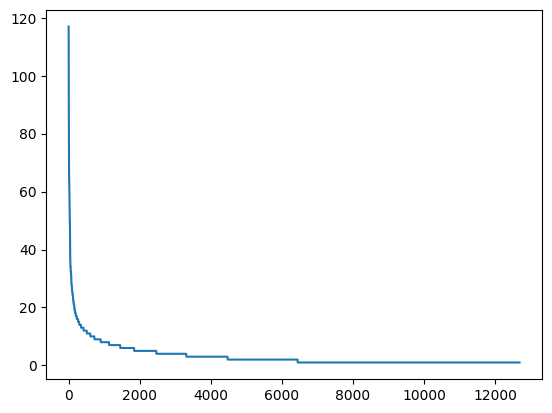

In [ ]:
import pymorphy3
import pandas as pd

morph = pymorphy3.MorphAnalyzer()


# Function to remove the first matching prefix
def remove_prefixes(word, prefixes):
    for prefix in prefixes:
        if len(word) - len(prefix) > 3 and word.startswith(prefix):
            return word[len(prefix) :]
    return word


# Function to remove the first matching suffix
def remove_suffixes(word, fixes):
    for f in fixes:
        if len(word) - len(f) > 2 and word.endswith(f):
            return word[: -len(f)]
    return word


# Cache pymorphy3 results to avoid recalculation
morph_cache = {}


def get_normal_form(word):
    if word not in morph_cache:
        morph_cache[word] = morph.parse(word)[0].normal_form
    return morph_cache[word]


# Apply prefix removal and normalization in one pass
prefixes_trash = ["-"]
prefixes_trash += [w.split("-")[0] + "-" for w in df_words_ru.word if "-" in w]
prefixes = [
    "много",
    "видео",
    "после",
    "супер",
    "фото",
    "водо",
    "обез",
    "осве",
    "осво",
    "пере",
    "полу",
    "пред",
    "само",
    "теле",
    "вось",
    "дву",
    "дис",
    "еже",
    "над",
    "под",
    "при",
    "пре",
    "про",
    "раз",
    "рас",
    "без",
    "бес",
    "воз",
    "вос",
    "вне",
    "вс",
    "вз",
    "вы",
    "до",
    "за",
    "им",
    "ин",
    "ис",
    "из",
    "не",
    "об",
    "от",
    "по",
    "со",
    "во",
    "с",
    "у",
    "в",
]
prefixes_sorted = sort_list(prefixes)

df_words_ru["word_no_prefix"] = df_words_ru["word"].copy()
for _ in range(1):
    df_words_ru["word_no_prefix"] = df_words_ru["word_no_prefix"].apply(
        lambda x: remove_prefixes(x, prefixes_trash)
    )
    # df_words_ru["word_no_prefix"] = df_words_ru["word_no_prefix"].apply(lambda x: remove_prefixes(x, prefixes_sorted))

df_words_ru["root"] = df_words_ru["word_no_prefix"].apply(get_normal_form)

df_words_ru["root"] = df_words_ru["root"].apply(
    lambda x: remove_prefixes(x, prefixes_trash)
)
for _ in range(2):
    df_words_ru["root"] = df_words_ru["root"].apply(
        lambda x: remove_prefixes(x, prefixes_sorted)
    )
    df_words_ru["root"] = df_words_ru["root"].apply(
        lambda x: remove_suffixes(x, ["ться", "ть"])
    )


# Group and sort
df_words_ru_root = (
    df_words_ru.groupby("root").agg({"word": list}).reset_index(drop=False)
)

df_words_ru_root["root_rev"] = df_words_ru_root.root.str[::-1]
df_words_ru_root["nwords"] = df_words_ru_root.word.apply(len)
df_words_ru_root = df_words_ru_root.sort_values("nwords", ascending=False).reset_index(
    drop=True
)

df_words_ru_root.to_csv("df_words_ru_root.csv", encoding="utf-8-sig", index=False)
print(df_words_ru.shape[0])
print(df_words_ru_root.shape[0])
display(df_words_ru_root)
df_words_ru_root.nwords.plot()

In [35]:
from itertools import chain


class TrieNode:
    def __init__(self):
        self.children = {}
        self.count = 0
        self.word_indices = []  # store indices of words passing through


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, index):
        node = self.root
        for ch in word:
            if ch not in node.children:
                node.children[ch] = TrieNode()
            node = node.children[ch]
            node.count += 1
            node.word_indices.append(index)


def find_longest_prefix_groups(words, min_group_size=2, min_prefix_len=3):
    """
    Iteratively find LONGEST prefixes having >= min_group_size words.
    Optimized: word indices are stored in trie nodes, so we avoid rescanning.
    """
    remaining = list(range(len(words)))  # track indices instead of words
    groups = {}

    while True:
        # Build trie for current remaining indices
        trie = Trie()
        for idx in remaining:
            trie.insert(words[idx], idx)

        new_groups = {}

        def dfs(node, prefix):
            found_child_group = False
            for ch, child in node.children.items():
                if child.count >= min_group_size:
                    dfs(child, prefix + ch)
                    found_child_group = True
            if (
                node.count >= min_group_size
                and not found_child_group
                and len(prefix) >= min_prefix_len
            ):
                new_groups[prefix] = [words[i] for i in node.word_indices]

        dfs(trie.root, "")

        if not new_groups:
            break

        groups.update(new_groups)
        grouped = set(chain.from_iterable(new_groups.values()))
        remaining = [i for i in remaining if words[i] not in grouped]

    singletons = [words[i] for i in remaining]
    return groups, singletons


# Example usage
words = df_words_ru_root.root

prefix_groups, prefix_singletons = find_longest_prefix_groups(
    words, min_group_size=2, min_prefix_len=3
)
prefix_groups = sort_dict(prefix_groups)


print(len(prefix_groups))
print(len(prefix_singletons))
for sub, words in prefix_groups.items():
    print(sub, words)

print(prefix_singletons)

4446
1629
про ['пробка', 'проход', 'проницаемый', 'прода', 'проща', 'прокат', 'провал', 'промах', 'пролив', 'профи', 'про']
пол ['полка', 'полис', 'полёт', 'поле', 'пол', 'полый', 'полюс', 'пола', 'полль', 'поляк']
при ['прийти', 'приём', 'пример', 'прибор', 'приход', 'прилёт', 'приезд', 'приют', 'при', 'приимчивый']
род ['роди', 'родный', 'рода', 'родливый', 'роды', 'род', 'родство', 'родригес', 'родковый', 'роде']
говор ['говори', 'говор', 'говорный', 'говорящий', 'говоры', 'говорённос', 'говорка', 'говорщик', 'говорчивый']
мак ['макмиллан', 'мак', 'макдауэлла', 'макс', 'макбрайд', 'макридти', 'макова', 'макет', 'макграт']
ман ['маныва', 'манчивый', 'манка', 'ману', 'манщик', 'маньяк', 'манжета', 'манго', 'манакин']
пере ['пере', 'перейти', 'перерыв', 'переезд', 'перец', 'переход', 'перепад', 'перекус', 'перебой']
тай ['тайский', 'тайный', 'тайванец', 'тайфун', 'тайгера', 'тайчжун', 'тайцзицюань', 'тайаня', 'тай-чи']
тан ['танец', 'танавлива', 'танцующий', 'танок', 'танин', 'танъюань

In [36]:
from itertools import chain


class TrieNode:
    def __init__(self):
        self.children = {}
        self.count = 0
        self.word_indices = []  # store indices of words passing through


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, index):
        node = self.root
        for ch in word:
            if ch not in node.children:
                node.children[ch] = TrieNode()
            node = node.children[ch]
            node.count += 1
            node.word_indices.append(index)


def find_longest_suffix_groups(words, min_group_size=2, min_suffix_len=3):
    """
    Iteratively find LONGEST suffixes having >= min_group_size words.
    Optimized: store word indices at nodes in trie of reversed words.
    """
    remaining = list(range(len(words)))  # indices
    groups = {}

    while True:
        trie = Trie()
        for idx in remaining:
            trie.insert(words[idx][::-1], idx)  # insert reversed word

        new_groups = {}

        def dfs(node, suffix_rev):
            found_child_group = False
            for ch, child in node.children.items():
                if child.count >= min_group_size:
                    dfs(child, suffix_rev + ch)
                    found_child_group = True
            if (
                node.count >= min_group_size
                and not found_child_group
                and len(suffix_rev) >= min_suffix_len
            ):
                suffix = suffix_rev[::-1]  # flip back to original direction
                new_groups[suffix] = [words[i] for i in node.word_indices]

        dfs(trie.root, "")

        if not new_groups:
            break

        groups.update(new_groups)
        grouped = set(chain.from_iterable(new_groups.values()))
        remaining = [i for i in remaining if words[i] not in grouped]

    singletons = [words[i] for i in remaining]
    return groups, singletons

# Example usage
words = df_words_ru_root.root

suffix_groups, suffix_singletons = find_longest_suffix_groups(
    words, min_group_size=2, min_suffix_len=3
)
suffix_groups = sort_dict(suffix_groups)

# Print results
print(len(suffix_groups))
print(len(suffix_singletons))

print("Shared suffix groups:")
for suffix, group_words in suffix_groups.items():
    print(f"'{suffix}' -> {group_words}")

print("\nSingletons (no shared suffix):")
print(suffix_singletons)


4178
1440
Shared suffix groups:
'ана' -> ['икебана', 'шана', 'сана', 'чанга-ана', 'енчмана', 'дайана', 'ана', 'нирвана', 'нана', 'наана', 'мегана']
'ать' -> ['дать', 'тать', 'чать', 'пать', 'кать', 'жать', 'щать', 'рать', 'мать', 'сать', 'вать']
'ида' -> ['ожида', 'кида', 'пирамида', 'флорида', 'обида', 'хакнида', 'кандида', 'ида', 'вида', 'пимеида', 'лида']
'ить' -> ['бить', 'жить', 'чить', 'пить', 'лить', 'сить', 'дить', 'шить', 'вить', 'нить', 'тить']
'лина' -> ['лина', 'длина', 'шлина', 'циплина', 'миндалина', 'клина', 'чилина', 'эйлина', 'данлина', 'патулина', 'маккуиллина']
'ирова' -> ['тренирова', 'графирова', 'реагирова', 'арьирова', 'тервьюирова', 'лидирова', 'тажирова', 'финиширова', 'ассоциирова', 'маскирова']
'истый' -> ['чистый', 'еребристый', 'пушистый', 'шелковистый', 'трит-истый', 'холмистый', 'хабистый', 'истый', 'золотистый', 'гольфистый']
'ковый' -> ['одинаковый', 'ковый', 'хлопковый', 'прыжковый', 'трептококковый', 'шпильковый', 'родковый', 'тивотанковый', 'рошковый

In [37]:
shared_sigletons = set(prefix_singletons).intersection(set(suffix_singletons))
unshared_sigletons = set(prefix_singletons).union(set(suffix_singletons)) - shared_sigletons
print(len(shared_sigletons))
print(len(unshared_sigletons))
print(shared_sigletons)
print(unshared_sigletons)

452
2165
{'у', 'готч', 'азот', 'эшли', 'г-жа', 'го', 'тх', 'ён', 'отум', 'он', 'из-за', 'храпе', 'сша', 'мм', 'ошва', 'ойна', 'зоя', 'нв', 'сак', 'г', 'аубергин', 'хозяин', 'фэнтези', 'зря', 'ааа', 'умие', 'мощь', 'боадицея', 'сея', 'льша', 'ад', 'люни', 'ппп', 'обыск', '-го', 'ацуп', 'на', 'олна', 'мяо', 'суи', 'сес', 'к-', 'бюро', 'энрике', 'гс', 'шмидт', 'этап', 'мс', 'уэйн', 'меч', 'меется', 'мяну', 'о', 'ми', 'х', 'слух', 'мы', 'ар', 'эм', 'чунцин', 'трёв', 'э', 'не', 'чис', 'нт', 'дауа', 'ой', 'слр', 'акм', 'по', 'куи', 'ьетнам', 'дэл', 'бийца', '-е', 'дуэт', 'уже', 'лчище', 'шорты', '-й', 'кедр', 'ху', 'кл', 'ээ', 'мэм', 'эн', 'лю', 'вау', 'эй-я', 'пк', 'веже', 'име', 'ос', 'из', 'плы', 'яо', 'мясо', 'обувь', 'арпеджио', 'эхо', 'пэн', 'дува', 'гб', 'снег', 'фельдшер', 'лмесяца', 'ти', 'би', 'ншугуйя', 'кляс', 'ужин', 'небо', 'тошни', 'ни', 'пцк', 'же', 'астма', 'аймы', 'ктк', 'ив', 'да', 'ушу', 'чехол', 'ям', 'до', 'эээ', 'эй', 'ю', 'фигня', 'рич', 'ггц', 'л', 'чи', 'пук', 'бо',

In [ ]:
from collections import defaultdict


def find_shared_substrings(words, min_group_size=2, min_length=2):
    """
    Find all substrings that appear in at least `min_group_size` words.
    Only consider substrings of length >= min_length.
    """
    substring_map = defaultdict(set)  # substring -> set of words

    for word in words:
        n = len(word)
        seen = set()  # avoid counting duplicate substrings in the same word
        # Generate all substrings of length >= min_length
        for start in range(n):
            for end in range(start + min_length, n + 1):
                sub = word[start:end]
                if sub not in seen:
                    substring_map[sub].add(word)
                    seen.add(sub)

    # Filter by min_group_size
    result = [
        (sub, list(word_set))
        for sub, word_set in substring_map.items()
        if len(word_set) >= min_group_size
    ]

    # Optionally, sort by substring length (longest first)
    result.sort(key=lambda x: (-len(x[0]), x[0]))
    return result


# Example usage
words = df_words_ru_root.root

shared_subs = find_shared_substrings(words, min_group_size=2, min_length=2)

# Deduplicate shared_subs by group_words, keep longest sub
deduped = {}
for sub, group_words in shared_subs:
    key = tuple(sorted(group_words))  # make group_words hashable
    if key not in deduped or len(sub) > len(deduped[key]):
        deduped[key] = sub

# Rebuild as list of (sub, group_words)
shared_subs_deduped = {sub: list(key) for key, sub in deduped.items()}
shared_subs_deduped = sort_dict(shared_subs_deduped)

print("Before deduplication:", len(shared_subs))
print("After deduplication:", len(shared_subs_deduped))
print("Deduplicated shared substrings:")
for sub, group_words in shared_subs_deduped.items():
    print(f"'{sub}' -> {group_words}")

Before deduplication: 29532
After deduplication: 14801
Deduplicated shared substrings:
'ый' -> ['абсолютный', 'абстрактный', 'авансовый', 'авантюрный', 'аварийный', 'авиапочтовый', 'авиационный', 'автобусный', 'автомобильный', 'автономный', 'авторитетный', 'автотранспортный', 'агрессивный', 'адебный', 'адекватный', 'административный', 'адовый', 'адочный', 'ажаемый', 'ажный', 'азартный', 'аимный', 'аимовыгодный', 'акантный', 'аккуратный', 'активный', 'актуальный', 'алатный', 'алидный', 'алкогольный', 'аловый', 'алфавитный', 'алый', 'альтернативный', 'алюминиевый', 'алютный', 'амбициозный', 'амбулаторный', 'амсонитовый', 'амый', 'аналогичный', 'аналоговый', 'ананасовый', 'англоязычный', 'анильный', 'анимационный', 'анитарный', 'анный', 'анонимный', 'антиблокировочный', 'антивирусный', 'антигистаминный', 'антикварный', 'античный', 'апельсиновый', 'аппаратный', 'аппетитный', 'арахисовый', 'арбитражный', 'арбузный', 'арендный', 'аренный', 'арительный', 'аркастичный', 'ароматизированный', 'а

In [39]:
middle_groups = {
    sub: group_words
    for sub, group_words in shared_subs_deduped.items()
    if not group_words[0].startswith(sub) and not group_words[0].endswith(sub) and len(sub)>3
}
middle_groups = sort_dict(middle_groups)
print(len(shared_subs_deduped))
print(len(middle_groups))
for sub, group_words in middle_groups.items():
    print(f"'{sub}' -> {group_words}")

14801
3178
'иров' -> ['адаптирова', 'администрирование', 'акклиматизирова', 'активизирова', 'активирова', 'альсирова', 'анализирова', 'анкетирование', 'аннулирова', 'анонсирова', 'антиблокировочный', 'апеллирова', 'аранжировка', 'ароматизированный', 'артикулирование', 'арьирова', 'ассоциирова', 'ассоциированный', 'базирова', 'балансирова', 'балансирование', 'балансированный', 'баллотирова', 'блокирова', 'блокирование', 'блокировщик', 'бомбардировка', 'бронирова', 'бронирование', 'бронированный', 'буксирова', 'буксировка', 'бюджетирова', 'волизирова', 'газирова', 'газировка', 'гарантирова', 'гарантированный', 'гармонирова', 'генерирова', 'гидратирова', 'гнозирова', 'гнозирование', 'госпитализирова', 'гофрированный', 'граммирова', 'граммирование', 'графирова', 'графирование', 'датирова', 'девальвирова', 'декларирова', 'декларирование', 'декорирование', 'демонстрирова', 'демонтирова', 'депонирова', 'депонирование', 'детализирова', 'диверсифицирова', 'дублирова', 'дублирование', 'ектирова'

In [27]:
import pymorphy3
from functools import lru_cache

morph = pymorphy3.MorphAnalyzer()
max_root_len = 8  # max expected root length

@lru_cache(maxsize=None)
def normalize_word(word: str) -> str:
    return morph.parse(word)[0].normal_form

@lru_cache(maxsize=None)
def is_known_word(word: str) -> bool:
    parses = morph.parse(word)
    return bool(parses and parses[0].is_known)

def build_roots(word_list):
    return {normalize_word(w) for w in word_list}

def is_valid_root(part: str, roots) -> bool:
    norm = normalize_word(part)
    return norm in roots or is_known_word(part)

def is_compound(word: str, roots):
    n = len(word)
    dp = [False] * (n + 1)
    dp[0] = True
    splits = [[] for _ in range(n+1)]

    for i in range(1, n + 1):
        for j in range(max(0, i - max_root_len), i):
            part = word[j:i]
            if dp[j] and is_valid_root(part, roots):
                dp[i] = True
                splits[i] = splits[j] + [part]
                break

    if dp[n] and len(splits[n]) > 1:
        return True, splits[n]
    return False, [word]

def find_compounds(word_list):
    roots = build_roots(word_list)
    compounds = {}
    for w in word_list:
        ok, parts = is_compound(w, roots)
        if ok:
            compounds[w] = parts
    return compounds



# ---------------- Example ----------------
if __name__ == "__main__":
    words = df_words_ru.word.to_list()
    
    compounds = find_compounds(words)
    
    for w, parts in compounds.items():
        print(f"{w} -> {parts}")


пожалуйста -> ['пожалуй', 'ста']
действительно -> ['дей', 'ст', 'ви', 'тельно']
несколько -> ['не', 'сколько']
что-нибудь -> ['что', '-', 'ни', 'будь']
некоторые -> ['не', 'которые']
правильно -> ['пра', 'вильно']
посмотреть -> ['по', 'смотреть']
интересно -> ['интерес', 'но']
пожаловать -> ['по', 'жаловать']
случилось -> ['с', 'лучилось']
собираюсь -> ['с', 'обираюсь']
здравствуйте -> ['з', 'дра', 'вс', 'тв', 'уй', 'те']
находится -> ['находит', 'с', 'я']
поговорить -> ['по', 'говорить']
достаточно -> ['до', 'статочно']
следующий -> ['с', 'ле', 'дующий']
позвольте -> ['поз', 'вольте']
проверить -> ['про', 'верить']
нормально -> ['нормаль', 'но']
когда-нибудь -> ['когда', '-', 'ни', 'будь']
посмотрим -> ['п', 'осмотрим']
рассказать -> ['рас', 'сказать']
заплатить -> ['за', 'платить']
позвонить -> ['по', 'звонить']
познакомиться -> ['поз', 'н', 'ако', 'мить', 'с', 'я']
последнее -> ['послед', 'нее']
большинство -> ['боль', 'шин', 'ст', 'во']
следующей -> ['с', 'ле', 'дующей']
английский

In [28]:
len(compounds)

16886